In [1]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# Download latest version
path = kagglehub.competition_download('bikeshare')

print("Path to competition files:", path)

100%|██████████| 131k/131k [00:00<00:00, 426kB/s]

Extracting files...
Path to competition files: /root/.cache/kagglehub/competitions/bikeshare


In [7]:
import pandas as pd
import numpy as np
import csv as csv
from datetime import datetime
import matplotlib.pyplot as plt


In [4]:

path = "/root/.cache/kagglehub/competitions/bikeshare"

train = pd.read_csv(f"{path}/train_luc.csv")
test = pd.read_csv(f"{path}/test_luc.csv")

train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9174 entries, 0 to 9173
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    9174 non-null   object 
 1   season      9174 non-null   int64  
 2   holiday     9174 non-null   int64  
 3   workingday  9174 non-null   int64  
 4   weather     9174 non-null   int64  
 5   temp        9174 non-null   float64
 6   atemp       9174 non-null   float64
 7   humidity    9174 non-null   int64  
 8   windspeed   9174 non-null   float64
 9   casual      9174 non-null   int64  
 10  registered  9174 non-null   int64  
 11  count       9174 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 860.2+ KB


## Understanding basic stats of the data set

In [6]:
train.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,9174.000000,9174.000000,9174.000000,9174.000000,9174.000000,9174.000000,9174.000000,9174.000000,9174.000000,9174.000000,9174.000000
mean,2.505559,0.031284,0.678875,1.414868,20.130401,23.578433,61.715064,12.737931,35.713647,154.868106,190.581753
std,1.116618,0.174094,0.466934,0.635363,7.940504,8.617957,19.401829,8.199027,49.667738,150.981155,181.011530
min,1.000000,0.000000,0.000000,1.000000,0.820000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,46.000000,7.001500,4.000000,35.000000,41.000000
50%,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,61.000000,11.001400,16.000000,117.000000,144.000000
75%,4.000000,0.000000,1.000000,2.000000,27.060000,31.060000,78.000000,16.997900,48.000000,222.000000,282.000000
max,4.000000,1.000000,1.000000,4.000000,41.000000,45.455000,100.000000,56.996900,362.000000,886.000000,977.000000


## Create a new feature

In [8]:
def hour_of_day(dt):
    return datetime.strptime(dt, "%Y-%m-%d %H:%M:%S").time().hour

train["hour"] = train["datetime"].map(hour_of_day)
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


## Make visualizations to inderstand data

hours:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


Text(0.5, 1.0, 'Measured bike use over 2 years')

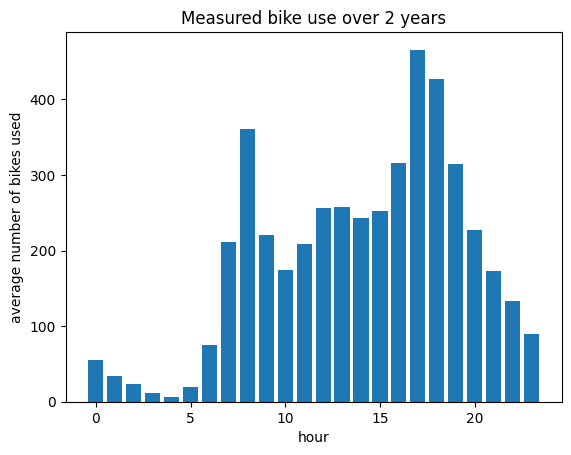

In [11]:
hours = np.unique(train["hour"])
print("hours: ", hours)

hours_mean = {}
for h in hours:
    temp_df = train.loc[train["hour"] == h]
    hours_mean[h] = temp_df['count'].mean()

# plot the results
plt.bar(hours, [hours_mean[h] for h in hours])
plt.xlabel("hour")
plt.ylabel("average number of bikes used")
plt.title("Measured bike use over 2 years")

## Pick the features and the model

In [34]:
cols = ["hour", "holiday", "temp", "workingday", "weather", "windspeed", "humidity"]

# from sklearn.tree import DecisionTreeRegressor
# from sklearn.linear_model import LinearRegression
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
print("Columns seected for later: ", cols)
print(model)


Columns seected for later:  ['hour', 'holiday', 'temp', 'workingday', 'weather', 'windspeed', 'humidity']
RandomForestRegressor()


## Seperate training and test sets

In [35]:
n = len(train)
training_size = 0.75

indices = np.array(range(n))
from numpy.random import shuffle
shuffle(indices)

split_point = int(n * training_size)
train_ind = indices[:split_point]
test_ind = indices[split_point:]

new_train_df = train.iloc[train_ind]
new_test_df = train.iloc[test_ind]

print("Samples in the new training subset: ", len(new_train_df))
print("Samples in the new test subset: ", len(new_test_df))

Samples in the new training subset:  6880
Samples in the new test subset:  2294


## Fit the model, test and evaluate

In [36]:
model.fit(new_train_df[cols], new_train_df["count"])

pred_count = model.predict(new_test_df[cols])

# Score the model
from sklearn.metrics import mean_squared_error
rms = np.sqrt(mean_squared_error(new_test_df["count"], pred_count))

print("RMS error: ", rms)

RMS error:  76.09111638665136


In [37]:
# read in the test data
test_df = pd.read_csv('/root/.cache/kagglehub/competitions/bikeshare/test_luc.csv', header=0)
print("\nNumber of samples:",test_df.shape[0] ,"and number of features:",test_df.shape[1],"\n")

# must add that new feature into the test data too, to use it in prediction
test_df['hour'] = test_df['datetime'].map(hour_of_day)

# show the test data output to be sure it read in correctly and added the column
test_df.head()

# fit the selected model TO YOUR FULL TRAINING SET
model.fit( train[cols], train['count'])

# apply to the test data FOR WHICH YOU DON'T HAVE THE ANSWERS
# (not the "test set" you used for model selection and tuning)
pred_count = model.predict(test_df[cols])

# add the prediction column (in case you want to inspect it later)
test_df['count'] = pred_count

# save the predicted count as a csv with a header column and datetime row
test_df = test_df[['datetime','count']].to_csv('my_prediction.csv',
    index=False, header=True)
print("Prediction complete. Saved as my_prediction.csv")


Number of samples: 1712 and number of features: 9 

Prediction complete. Saved as my_prediction.csv
